In [182]:
import numpy as np
import scipy.stats as scs
from matplotlib import pyplot as plt
from tqdm import tqdm
from scipy.spatial.distance import pdist
from sklearn.gaussian_process.kernels import Matern
import torch
import torch.nn as nn

In [183]:
def Spatial_Energy_Score_sublocs(theta,beta,sub_locs,days_nb,sim_nb,observations_x,censor_levels_di,dist_matrix,topo_matrix=None):
    '''
    theta: vector of 3 [Matern_param, coef_distmat, coef_topomat]. The coefs are applied to the matricies to form the ditance matrix used as input in the Matern kernel to form the covariance.
    sub_locs: a set of subsets of location indexes with the same number of locs in each.
    days_nb: how many days to include on the subsample.
    sim_nb: number of simulation draws to compare with original data in the score.
    observations_x: x, observed rainfall transformed to a Gaussian normal scale. This is the data that we try to emulate.
    censor_levels_di: d, probability of no rain (1-p) transformed to a normal scale. These are used to censor simulations (x') when comparingt to x.
    '''
    # Subsample locations. Choose a random subset the list of subsets - sub_locs.
    locs = sub_locs[np.random.choice(range(len(sub_locs)))] 
    locs_nb = len(locs)
    # Subsample days.
    days = np.random.choice(range(len(observations_x)),size=days_nb,replace=False)

    # Select relevant subsamples of data.
    x = observations_x[days,:][:,locs]
    d = censor_levels_di[days,:][:,locs]
    
    # Create covariance matrix.
    if np.sum(topo_matrix==None):
        cov_mat = np.nan_to_num(Matern(length_scale=theta,nu=3.5).__call__(dist_matrix[locs,:][:,locs]))
    else:
        cov_mat = np.nan_to_num(Matern(length_scale=theta[0],nu=3.5).__call__(theta[1]*dist_mat[locs,:][:,locs]+((1-theta[1])/70)*topo_dist[locs,:][:,locs]))

    # Draw samples from the multivariate nromal with appropriate covariance.
    simulations = scs.multivariate_normal(mean=np.zeros(locs_nb),cov=cov_mat,allow_singular=True).rvs(size=sim_nb)
    
    # Censor simulated values and format them into [[sim0-day0,sim0-day1,...,sim0-dayn] ,..., [sim_m-day0,sim_m-day1,...,sim_m-dayn]]. Gives sim_nb*days_nb=m*n vectors of len=locs_nb. 
    censored_sims = np.maximum(np.repeat(simulations,days_nb,axis=0),np.tile(d,(sim_nb,1)))

    # ||x' - x' ||_2 component of energy score
    sims_by_day = [censored_sims[0+k::days_nb] for k in range(days_nb)] # regroup to get [[sim(1,day1), sim(2,day1),...,sim(m,day1)],...,[sim(1,dayn), sim(2,dayn),...,sim(m,dayn)]].
    
    sim_L2_diff = 0
    
    for sim_day_i in sims_by_day: # don't know how to make it more efficient... maybe can parallelize to compute complete score
        
        # ||x' - x' ||_2 component of energy score
            # OLD: einsum from Lorenzos code on each sim_day_i was 9x slower then doing pdist on each sim_day_i. Both give the same answer
        '''
        # matrix of all combinations over i of [vector_i-vector_1, ... , vector_i-vector_n]
        temp_diff_combinations_matrix = sim_day_i.reshape(1,sim_nb,locs_nb)-sim_day_i.reshape(sim_nb,1,locs_nb) 
        # einsum creates a matrix of sum of squares, then take sqrt to get L2.
        sim_L2_diff+=0.5*np.sum(np.sqrt(np.einsum('ijk, ijk -> ij',temp_diff_combinations_matrix,temp_diff_combinations_matrix))) 
        '''
            # New: pdist takes the offdiagonal of an L2 distance matrix, only counting once each combination of Y,Y'.
        sim_L2_diff+= 2 * np.sum(np.power(pdist(sim_day_i),beta))

    # Add both parts of Energy.
    Energy = 2 * np.mean(np.power(np.linalg.norm(censored_sims - np.tile(x,(sim_nb,1)),axis=1),beta)) - sim_L2_diff/(days_nb*sim_nb*(sim_nb-1))
    
    
    #path_.append([theta,Energy])
    print([theta,Energy])

    return Energy

path_avg = []

def Spatial_Energy_Score_sublocs_averaged(theta,beta,sub_locs,days_nb,sim_nb,observations_x,censor_levels_di,dist_matrix,topo_matrix,avg_nb):
    avg_SR = 0

    for s in range(avg_nb):
        avg_SR+= Spatial_Energy_Score_sublocs(theta,beta,sub_locs,days_nb,sim_nb,observations_x,censor_levels_di,dist_matrix,topo_matrix)

    path_avg.append(avg_SR/avg_nb)
    
    return avg_SR/avg_nb

# Minimal examples

## 2D Gaussian with $\rho$ directly

In [184]:
def Energy_Score(energy_beta, observations_y, simulations_Y):
    m = len(simulations_Y)
    diff_Y_y = torch.pow(
        torch.norm(
            (observations_y.unsqueeze(1) -
             simulations_Y.unsqueeze(0)).float(),
            dim=2, keepdim=True).reshape(-1, 1),
        energy_beta)
    diff_Y_Y = 2 * torch.pow(
        nn.functional.pdist(simulations_Y),
        energy_beta)
    Energy = 2 * torch.mean(diff_Y_y) - torch.sum(diff_Y_Y) / (m * (m - 1))
    return Energy

### 2D Fully observed Gaussian copula inference of $\rho$ directly

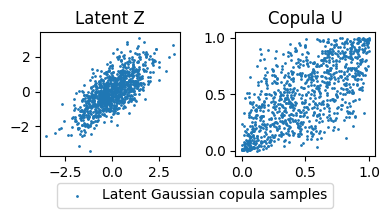

In [185]:
# generate Gaussian data for copula

latent_z = scs.multivariate_normal.rvs(mean=[0, 0], cov=[[1, 0.7], [0.7, 1]], size=1000)
copula_u = scs.norm.cdf(latent_z)
fig, axes = plt.subplots(1, 2, figsize=(4, 2))

axes[0].scatter(latent_z[:, 0], latent_z[:, 1], s=1, label='Latent Gaussian copula samples')
axes[0].set_title('Latent Z')

axes[1].scatter(copula_u[:, 0], copula_u[:, 1], s=1)
axes[1].set_title('Copula U')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.tight_layout()
plt.show()

In [195]:
# On the Gaussian Scale
def sample_Gauss_2d(n, cov):
    latent_z = scs.multivariate_normal.rvs(mean=np.zeros(cov.shape[0]), cov=cov, size=n)
    return latent_z

def sample_Gauss_2d_fixed_noise(n, noise, chol_cov):
    latent_z = noise @ chol_cov.T
    return latent_z
fixed_noise = scs.norm.rvs(size=(1000, 2))

e_scores_per_rho = []
beta = 0.5
for i in tqdm(range(100)):
    rho = np.round((i+1)/101,2)
    chol_cov = np.linalg.cholesky([[1, rho], [rho, 1]])
    gauss2d_fixed_samples = sample_Gauss_2d_fixed_noise(1000, fixed_noise, chol_cov)
    gauss2d_samples = sample_Gauss_2d(1000, cov=np.array([[1, rho], [rho, 1]]))
    e_scores_per_rho.append([Energy_Score(beta, torch.tensor(latent_z), torch.tensor(gauss2d_samples)),Energy_Score(beta, torch.tensor(latent_z), torch.tensor(gauss2d_fixed_samples)),rho])

# On the Copula Scale
def sample_Gauss_2d_copula(n, cov):
    latent_z = scs.multivariate_normal.rvs(mean=np.zeros(cov.shape[0]), cov=cov, size=n)
    return scs.norm.cdf(np.clip(latent_z, -7, 7))

def sample_Gauss_2d_fixed_noise_copula(n, noise, chol_cov):
    latent_z = noise @ chol_cov.T
    return scs.norm.cdf(np.clip(latent_z, -7, 7))
fixed_noise = scs.norm.rvs(size=(1000, 2))

e_scores_per_rho_cop = []
beta = 0.5
for i in tqdm(range(100)):
    rho = np.round((i+1)/101,2)
    chol_cov = np.linalg.cholesky([[1, rho], [rho, 1]])
    cop2d_fixed_samples = sample_Gauss_2d_fixed_noise_copula(1000, fixed_noise, chol_cov)
    cop2d_samples = sample_Gauss_2d_copula(1000, cov=np.array([[1, rho], [rho, 1]]))
    e_scores_per_rho_cop.append([Energy_Score(beta, torch.tensor(copula_u), torch.tensor(cop2d_samples)),Energy_Score(beta, torch.tensor(copula_u), torch.tensor(cop2d_fixed_samples)),rho])


100%|██████████| 100/100 [00:02<00:00, 39.00it/s]


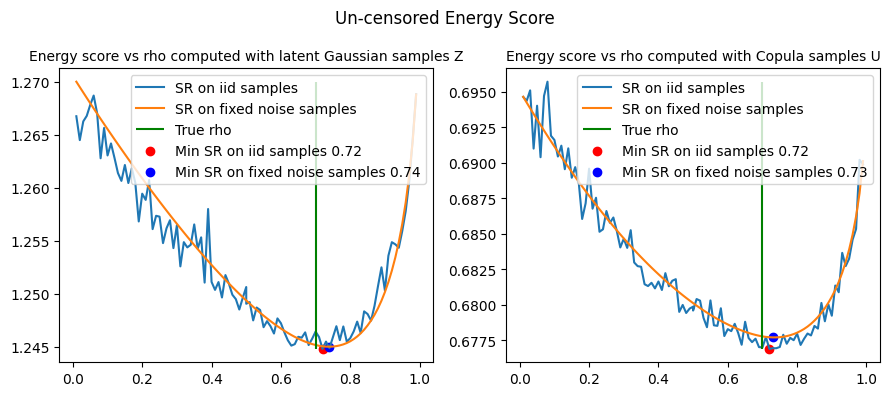

In [196]:
e_scores_per_rho = np.array(e_scores_per_rho)
e_scores_per_rho_cop = np.array(e_scores_per_rho_cop)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Plot for latent Gaussian samples Z
axes[0].set_title('Energy score vs rho computed with latent Gaussian samples Z',fontsize=10)
axes[0].plot(e_scores_per_rho[:, 2], e_scores_per_rho[:, 0], label='SR on iid samples')
axes[0].plot(e_scores_per_rho[:, 2], e_scores_per_rho[:, 1], label='SR on fixed noise samples')
axes[0].vlines(0.7, e_scores_per_rho[:, 0:2].min(), e_scores_per_rho[:, 0:2].max(), color='green', label='True rho')
axes[0].scatter(e_scores_per_rho[np.argmin(e_scores_per_rho[:, 0]), 2], e_scores_per_rho[np.argmin(e_scores_per_rho[:, 0]), 0], color='red', label=f'Min SR on iid samples {e_scores_per_rho[np.argmin(e_scores_per_rho[:, 0]), 2]}')
axes[0].scatter(e_scores_per_rho[np.argmin(e_scores_per_rho[:, 1]), 2], e_scores_per_rho[np.argmin(e_scores_per_rho[:, 1]), 1], color='blue', label=f'Min SR on fixed noise samples {e_scores_per_rho[np.argmin(e_scores_per_rho[:, 1]), 2]}')
axes[0].legend()

# Plot for Copula samples U
axes[1].set_title('Energy score vs rho computed with Copula samples U',fontsize=10)
axes[1].plot(e_scores_per_rho_cop[:, 2], e_scores_per_rho_cop[:, 0], label='SR on iid samples')
axes[1].plot(e_scores_per_rho_cop[:, 2], e_scores_per_rho_cop[:, 1], label='SR on fixed noise samples')
axes[1].vlines(0.7, e_scores_per_rho_cop[:, 0:2].min(), e_scores_per_rho_cop[:, 0:2].max(), color='green', label='True rho')
axes[1].scatter(e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 0]), 2], e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 0]), 0], color='red', label=f'Min SR on iid samples {e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 0]), 2]}')
axes[1].scatter(e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 1]), 2], e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 1]), 1], color='blue', label=f'Min SR on fixed noise samples {e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 1]), 2]}')
axes[1].legend()

fig.suptitle('Un-censored Energy Score')
plt.tight_layout()
plt.show()

### 2D Censored Gaussian copula inference of $\rho$ directly

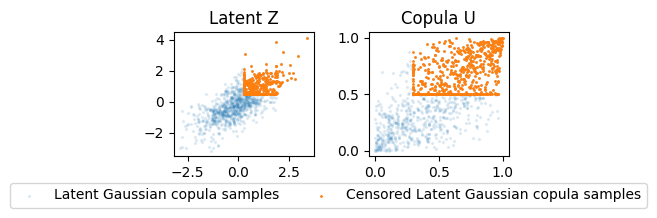

In [188]:
# generate censored Gaussian data for copula

latent_z = scs.multivariate_normal.rvs(mean=[0, 0], cov=[[1, 0.7], [0.7, 1]], size=1000)
copula_u = scs.norm.cdf(latent_z)
censor_lvl = np.array([0.3,0.5])
latent_z_censored = np.maximum(latent_z,censor_lvl)
copula_u_censored = np.maximum(copula_u,censor_lvl)
fig, axes = plt.subplots(1, 2, figsize=(4, 2))

axes[0].scatter(latent_z[:, 0], latent_z[:, 1], s=2,alpha=0.1, label='Latent Gaussian copula samples')
axes[0].scatter(latent_z_censored[:, 0], latent_z_censored[:, 1], s=1, label='Censored Latent Gaussian copula samples')
axes[0].set_title('Latent Z')

axes[1].scatter(copula_u[:, 0], copula_u[:, 1], s=2,alpha=0.1)
axes[1].scatter(copula_u_censored[:,0],copula_u_censored[:,1],s=1)
axes[1].set_title('Copula U')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.tight_layout()
plt.show()

In [193]:
# On the Gaussian Scale
def sample_Gauss_2d(n, cov):
    latent_z = scs.multivariate_normal.rvs(mean=np.zeros(cov.shape[0]), cov=cov, size=n)
    return latent_z

def sample_Gauss_2d_fixed_noise(n, noise, chol_cov):
    latent_z = noise @ chol_cov.T
    return latent_z
fixed_noise = scs.norm.rvs(size=(1000, 2))

cens_e_scores_per_rho = []
beta = 0.5
for i in tqdm(range(100)):
    rho = np.round((i+1)/101,2)
    chol_cov = np.linalg.cholesky([[1, rho], [rho, 1]])
    gauss2d_fixed_samples = sample_Gauss_2d_fixed_noise(1000, fixed_noise, chol_cov)
    gauss2d_fixed_samples_censored = np.maximum(gauss2d_fixed_samples,censor_lvl)
    gauss2d_samples = sample_Gauss_2d(1000, cov=np.array([[1, rho], [rho, 1]]))
    gauss2d_samples_censored = np.maximum(gauss2d_samples,censor_lvl)
    cens_e_scores_per_rho.append([Energy_Score(beta, torch.tensor(latent_z_censored), torch.tensor(gauss2d_samples_censored)),Energy_Score(beta, torch.tensor(latent_z_censored), torch.tensor(gauss2d_fixed_samples_censored)),rho])

# On the Copula Scale
def sample_Gauss_2d_copula(n, cov):
    latent_z = scs.multivariate_normal.rvs(mean=np.zeros(cov.shape[0]), cov=cov, size=n)
    return scs.norm.cdf(np.clip(latent_z, -7, 7))

def sample_Gauss_2d_fixed_noise_copula(n, noise, chol_cov):
    latent_z = noise @ chol_cov.T
    return scs.norm.cdf(np.clip(latent_z, -7, 7))
fixed_noise = scs.norm.rvs(size=(1000, 2))

cens_e_scores_per_rho_cop = []
beta = 0.5
for i in tqdm(range(100)):
    rho = np.round((i+1)/101,2)
    chol_cov = np.linalg.cholesky([[1, rho], [rho, 1]])
    cop2d_fixed_samples = sample_Gauss_2d_fixed_noise_copula(1000, fixed_noise, chol_cov)
    cop2d_fixed_samples_censored = np.maximum(cop2d_fixed_samples,censor_lvl)
    cop2d_samples = sample_Gauss_2d_copula(1000, cov=np.array([[1, rho], [rho, 1]]))
    cop2d_samples_censored = np.maximum(cop2d_samples,censor_lvl)
    cens_e_scores_per_rho_cop.append([Energy_Score(beta, torch.tensor(copula_u_censored), torch.tensor(cop2d_samples_censored)),Energy_Score(beta, torch.tensor(copula_u_censored), torch.tensor(cop2d_fixed_samples_censored)),rho])


100%|██████████| 100/100 [00:02<00:00, 35.73it/s]


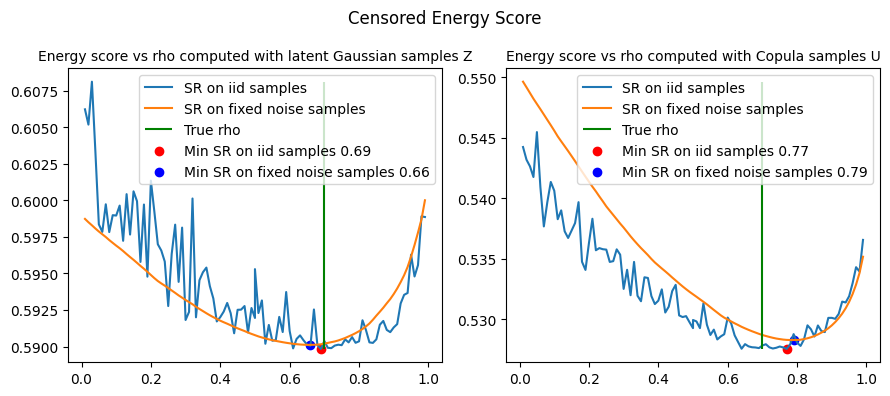

In [194]:

# Convert to numpy arrays
cens_e_scores_per_rho = np.array(cens_e_scores_per_rho)
cens_e_scores_per_rho_cop = np.array(cens_e_scores_per_rho_cop)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Plot for latent Gaussian samples Z
fig.suptitle('Censored Energy Score')

axes[0].set_title('Energy score vs rho computed with latent Gaussian samples Z', fontsize=10)
axes[0].plot(cens_e_scores_per_rho[:, 2], cens_e_scores_per_rho[:, 0], label='SR on iid samples')
axes[0].plot(cens_e_scores_per_rho[:, 2], cens_e_scores_per_rho[:, 1], label='SR on fixed noise samples')
axes[0].vlines(0.7, cens_e_scores_per_rho[:, 0:2].min(), cens_e_scores_per_rho[:, 0:2].max(), color='green', label='True rho')
axes[0].scatter(cens_e_scores_per_rho[np.argmin(cens_e_scores_per_rho[:, 0]), 2], cens_e_scores_per_rho[np.argmin(cens_e_scores_per_rho[:, 0]), 0], color='red', label=f'Min SR on iid samples {cens_e_scores_per_rho[np.argmin(cens_e_scores_per_rho[:, 0]), 2]}')
axes[0].scatter(cens_e_scores_per_rho[np.argmin(cens_e_scores_per_rho[:, 1]), 2], cens_e_scores_per_rho[np.argmin(cens_e_scores_per_rho[:, 1]), 1], color='blue', label=f'Min SR on fixed noise samples {cens_e_scores_per_rho[np.argmin(cens_e_scores_per_rho[:, 1]), 2]}')
axes[0].legend()

# Plot for Copula samples U
axes[1].set_title('Energy score vs rho computed with Copula samples U', fontsize=10)
axes[1].plot(cens_e_scores_per_rho_cop[:, 2], cens_e_scores_per_rho_cop[:, 0], label='SR on iid samples')
axes[1].plot(cens_e_scores_per_rho_cop[:, 2], cens_e_scores_per_rho_cop[:, 1], label='SR on fixed noise samples')
axes[1].vlines(0.7, cens_e_scores_per_rho_cop[:, 0:2].min(), cens_e_scores_per_rho_cop[:, 0:2].max(), color='green', label='True rho')
axes[1].scatter(cens_e_scores_per_rho_cop[np.argmin(cens_e_scores_per_rho_cop[:, 0]), 2], cens_e_scores_per_rho_cop[np.argmin(cens_e_scores_per_rho_cop[:, 0]), 0], color='red', label=f'Min SR on iid samples {cens_e_scores_per_rho_cop[np.argmin(cens_e_scores_per_rho_cop[:, 0]), 2]}')
axes[1].scatter(cens_e_scores_per_rho_cop[np.argmin(cens_e_scores_per_rho_cop[:, 1]), 2], cens_e_scores_per_rho_cop[np.argmin(cens_e_scores_per_rho_cop[:, 1]), 1], color='blue', label=f'Min SR on fixed noise samples {cens_e_scores_per_rho_cop[np.argmin(cens_e_scores_per_rho_cop[:, 1]), 2]}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 2D Gaussian with $\theta$ with a GPK 

In [205]:
from sklearn.metrics.pairwise import euclidean_distances 

locations = np.array([[0, 0], [10, 10]])
dist_matrix = euclidean_distances(locations, locations)
true_cov = Matern(length_scale=30, nu=3.5).__call__(dist_matrix)
true_cov


array([[1.        , 0.74966344],
       [0.74966344, 1.        ]])

### 2D Fully observed Gaussian copula inference of $\theta$ with GPK

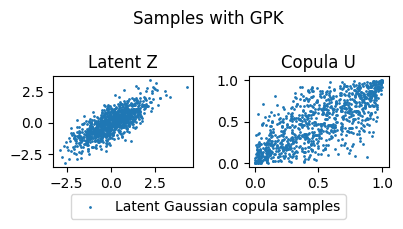

In [207]:
# generate Gaussian data for copula

latent_z = scs.multivariate_normal.rvs(mean=[0, 0], cov=true_cov, size=1000)
copula_u = scs.norm.cdf(latent_z)
fig, axes = plt.subplots(1, 2, figsize=(4, 2))

axes[0].scatter(latent_z[:, 0], latent_z[:, 1], s=1, label='Latent Gaussian copula samples')
axes[0].set_title('Latent Z')

axes[1].scatter(copula_u[:, 0], copula_u[:, 1], s=1)
axes[1].set_title('Copula U')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2)
fig.suptitle('Samples with GPK')
plt.tight_layout()
plt.show()

In [211]:
# On the Gaussian Scale
def sample_Gauss_2d(n, cov):
    latent_z = scs.multivariate_normal.rvs(mean=np.zeros(cov.shape[0]), cov=cov, size=n)
    return latent_z

def sample_Gauss_2d_fixed_noise(n, noise, chol_cov):
    latent_z = noise @ chol_cov.T
    return latent_z
fixed_noise = scs.norm.rvs(size=(1000, 2))

e_scores_per_rho = []
beta = 0.5
for i in tqdm(range(99)):
    estimated_cov = Matern(length_scale=i+1, nu=3.5).__call__(dist_matrix)
    chol_cov = np.linalg.cholesky(estimated_cov)
    gauss2d_fixed_samples = sample_Gauss_2d_fixed_noise(1000, fixed_noise, chol_cov)
    gauss2d_samples = sample_Gauss_2d(1000, cov=estimated_cov)
    e_scores_per_rho.append([Energy_Score(beta, torch.tensor(latent_z), torch.tensor(gauss2d_samples)),Energy_Score(beta, torch.tensor(latent_z), torch.tensor(gauss2d_fixed_samples)),i+1])

# On the Copula Scale
def sample_Gauss_2d_copula(n, cov):
    latent_z = scs.multivariate_normal.rvs(mean=np.zeros(cov.shape[0]), cov=cov, size=n)
    return scs.norm.cdf(np.clip(latent_z, -7, 7))

def sample_Gauss_2d_fixed_noise_copula(n, noise, chol_cov):
    latent_z = noise @ chol_cov.T
    return scs.norm.cdf(np.clip(latent_z, -7, 7))
fixed_noise = scs.norm.rvs(size=(1000, 2))

e_scores_per_rho_cop = []
beta = 0.5
for i in tqdm(range(100)):
    estimated_cov = Matern(length_scale=i+1, nu=3.5).__call__(dist_matrix)
    chol_cov = np.linalg.cholesky(estimated_cov)
    cop2d_fixed_samples = sample_Gauss_2d_fixed_noise_copula(1000, fixed_noise, chol_cov)
    cop2d_samples = sample_Gauss_2d_copula(1000, cov=estimated_cov)
    e_scores_per_rho_cop.append([Energy_Score(beta, torch.tensor(copula_u), torch.tensor(cop2d_samples)),Energy_Score(beta, torch.tensor(copula_u), torch.tensor(cop2d_fixed_samples)),i+1])


100%|██████████| 100/100 [00:03<00:00, 32.05it/s]


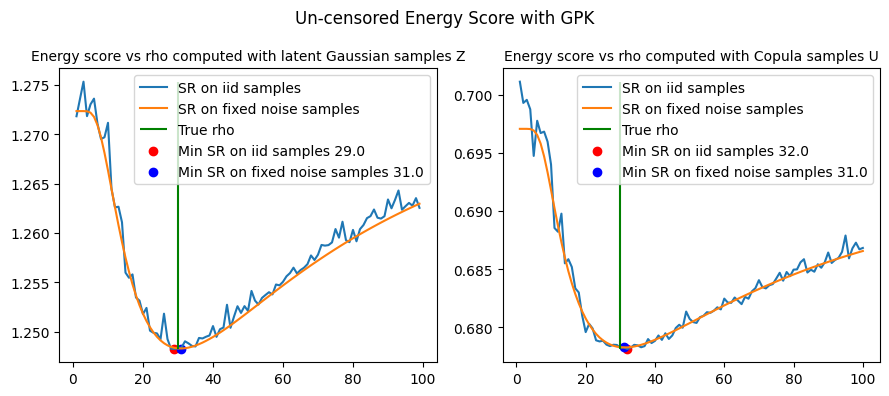

In [213]:
e_scores_per_rho = np.array(e_scores_per_rho)
e_scores_per_rho_cop = np.array(e_scores_per_rho_cop)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Plot for latent Gaussian samples Z
axes[0].set_title('Energy score vs rho computed with latent Gaussian samples Z',fontsize=10)
axes[0].plot(e_scores_per_rho[:, 2], e_scores_per_rho[:, 0], label='SR on iid samples')
axes[0].plot(e_scores_per_rho[:, 2], e_scores_per_rho[:, 1], label='SR on fixed noise samples')
axes[0].vlines(30, e_scores_per_rho[:, 0:2].min(), e_scores_per_rho[:, 0:2].max(), color='green', label='True rho')
axes[0].scatter(e_scores_per_rho[np.argmin(e_scores_per_rho[:, 0]), 2], e_scores_per_rho[np.argmin(e_scores_per_rho[:, 0]), 0], color='red', label=f'Min SR on iid samples {e_scores_per_rho[np.argmin(e_scores_per_rho[:, 0]), 2]}')
axes[0].scatter(e_scores_per_rho[np.argmin(e_scores_per_rho[:, 1]), 2], e_scores_per_rho[np.argmin(e_scores_per_rho[:, 1]), 1], color='blue', label=f'Min SR on fixed noise samples {e_scores_per_rho[np.argmin(e_scores_per_rho[:, 1]), 2]}')
axes[0].legend()

# Plot for Copula samples U
axes[1].set_title('Energy score vs rho computed with Copula samples U',fontsize=10)
axes[1].plot(e_scores_per_rho_cop[:, 2], e_scores_per_rho_cop[:, 0], label='SR on iid samples')
axes[1].plot(e_scores_per_rho_cop[:, 2], e_scores_per_rho_cop[:, 1], label='SR on fixed noise samples')
axes[1].vlines(30, e_scores_per_rho_cop[:, 0:2].min(), e_scores_per_rho_cop[:, 0:2].max(), color='green', label='True rho')
axes[1].scatter(e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 0]), 2], e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 0]), 0], color='red', label=f'Min SR on iid samples {e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 0]), 2]}')
axes[1].scatter(e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 1]), 2], e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 1]), 1], color='blue', label=f'Min SR on fixed noise samples {e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 1]), 2]}')
axes[1].legend()

fig.suptitle('Un-censored Energy Score with GPK')
plt.tight_layout()
plt.show()

### 2D Censored Gaussian copula inference of $\theta$ with GPK

In [ ]:
# generate censored Gaussian data for copula

latent_z = scs.multivariate_normal.rvs(mean=[0, 0], cov=[[1, 0.7], [0.7, 1]], size=1000)
copula_u = scs.norm.cdf(latent_z)
censor_lvl = np.array([0.3,0.5])
latent_z_censored = np.maximum(latent_z,censor_lvl)
copula_u_censored = np.maximum(copula_u,censor_lvl)
fig, axes = plt.subplots(1, 2, figsize=(4, 2))

axes[0].scatter(latent_z[:, 0], latent_z[:, 1], s=2,alpha=0.1, label='Latent Gaussian copula samples')
axes[0].scatter(latent_z_censored[:, 0], latent_z_censored[:, 1], s=1, label='Censored Latent Gaussian copula samples')
axes[0].set_title('Latent Z')

axes[1].scatter(copula_u[:, 0], copula_u[:, 1], s=2,alpha=0.1)
axes[1].scatter(copula_u_censored[:,0],copula_u_censored[:,1],s=1)
axes[1].set_title('Copula U')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.tight_layout()
plt.show()